In [36]:
# Download images from GitHub folder
!apt-get install git-lfs
!git clone https://github.com/ylwong98/DATA607_What-Classifies-Wildlife-Better---Context-or-Pixels-.git

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
fatal: destination path 'DATA607_What-Classifies-Wildlife-Better---Context-or-Pixels-' already exists and is not an empty directory.


In [37]:
# set path to downloaded image folder ~ should line up with above chuck in Google Colab execution
image_location = '/content/DATA607_What-Classifies-Wildlife-Better---Context-or-Pixels-/images/'

In [38]:
import os
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
import glob
import time


print(time.ctime())
#define four directorys/classes
Classification_Definition = ['birds','large_carnivores','small_mammals','ungulates']
image_directory = {}

for animal in Classification_Definition:
    # Define the directory where images are stored
    image_dir = image_location + animal
    # Get a list of all image files in the directory
    image_paths = glob.glob(os.path.join(image_dir, '*.jpg'))

    #collect file names in single array
    imagesFileLocation = []

    for img_path in image_paths:
        imagesFileLocation.append(img_path)

    image_directory[animal] = imagesFileLocation

for animal_species in image_directory:
        print("Animal:",animal_species,"has",len(image_directory[animal_species]), "pictures")

print(time.ctime())

Sun Apr  5 01:59:56 2026
Animal: birds has 100 pictures
Animal: large_carnivores has 100 pictures
Animal: small_mammals has 100 pictures
Animal: ungulates has 100 pictures
Sun Apr  5 01:59:56 2026


In [39]:
#using pillow, load each image, converting to 256x256 dimension
#convert to RGB channel
#print shapes of X and y to confirm sizes for CNN

print(time.ctime())
images = []
animal_species_class = []
image_size = (224, 224) # Define a size for all images


for animal_species in image_directory:
    print("Processing:",animal_species)
    LiveCounter = 1
    for img_path in image_directory[animal_species]:
        if(LiveCounter % 500 == 0):
            print(animal_species," - LiveCounter:",LiveCounter)

        try:
            img = Image.open(img_path).convert('RGB') # Ensure image is in RGB format
            img = img.resize(image_size) # Resize the image
            images.append(np.array(img)) # Convert to NumPy array
            animal_species_class.append(np.array(animal_species)) # Convert to NumPy array
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")

        LiveCounter += 1


# Convert the list of image arrays into a single NumPy array
X = np.array(images)
y = np.array(animal_species_class)

print(f"Shape of the image data array (X): {X.shape}")
print(f"Data type of the image data array: {X.dtype}")

print(f"Shape of the response data array (y): {y.shape}")
print(f"Data type of the response data array: {y.dtype}")

print(time.ctime())

Sun Apr  5 01:59:56 2026
Processing: birds
Processing: large_carnivores
Processing: small_mammals
Processing: ungulates
Shape of the image data array (X): (400, 224, 224, 3)
Data type of the image data array: uint8
Shape of the response data array (y): (400,)
Data type of the response data array: <U16
Sun Apr  5 02:00:00 2026


In [40]:
print(time.ctime())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("Data preparation complete! You now have X_train, X_test, y_train, and y_test ready for your CNN.")
print(time.ctime())

Sun Apr  5 02:00:00 2026
Shape of X_train: (340, 224, 224, 3)
Shape of X_test: (60, 224, 224, 3)
Shape of y_train: (340,)
Shape of y_test: (60,)
Data preparation complete! You now have X_train, X_test, y_train, and y_test ready for your CNN.
Sun Apr  5 02:00:00 2026


In [41]:
#create validation data
print(time.ctime())
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, stratify=y_train, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")

print("Data preparation complete! You now have X_train, X_val, y_train, and y_val ready for your CNN.")
print(time.ctime())

Sun Apr  5 02:00:00 2026
Shape of X_train: (289, 224, 224, 3)
Shape of X_val: (51, 224, 224, 3)
Shape of y_train: (289,)
Shape of y_val: (51,)
Data preparation complete! You now have X_train, X_val, y_train, and y_val ready for your CNN.
Sun Apr  5 02:00:00 2026


In [42]:
import time
import tensorflow as tf
from tensorflow.keras import layers, models

print(time.ctime())

# Define the CNN model using the updated Input layer style
model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]), # Define input shape here
    layers.Conv2D(32, (3, 3), activation='relu'), # Remove input_shape from here
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(Classification_Definition), activation='softmax')
])

# Display the model summary
model.summary()
print(time.ctime())

Sun Apr  5 02:00:00 2026


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 173056)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │    11,075,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,132,228 (42.47 MB)

 Trainable params: 11,132,228 (42.47 MB)

 Non-trainable params: 0 (0.00 B)

Sun Apr  5 02:00:00 2026


In [43]:
print(time.ctime())

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print(time.ctime())

Sun Apr  5 02:00:00 2026
Sun Apr  5 02:00:00 2026


In [44]:
print(time.ctime())
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit on the entire 'y' array to ensure all unique labels are encoded consistently
# and then transform y_train and y_test
# We're transforming y (all original labels) to get the full mapping, then transforming y_train and y_test separately
# Alternatively, fit on y_train and transform both y_train and y_test

# First, combine y_train and y_test to fit the encoder across all possible labels
# This ensures that the same integer is assigned to the same class across both sets
y_combined = np.concatenate((y_train, y_val, y_test), axis=0)
label_encoder.fit(y_combined)

y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

# Print the first few encoded labels and original labels to verify
print(f"Original y_train labels (first 5): {y_train[:5]}")
print(f"Encoded y_train labels (first 5): {y_train_encoded[:5]}")
print(f"Original y_val labels (first 5): {y_val[:5]}")
print(f"Encoded y_val labels (first 5): {y_val_encoded[:5]}")
print(f"Original y_test labels (first 5): {y_test[:5]}")
print(f"Encoded y_test labels (first 5): {y_test_encoded[:5]}")

print(f"Unique classes and their encoded values: {list(label_encoder.classes_)} -> {label_encoder.transform(label_encoder.classes_)}")

# Now, reassign y_train and y_test to their encoded versions
y_train = y_train_encoded
y_val = y_val_encoded
y_test = y_test_encoded

print(f"Shape of encoded y_train: {y_train.shape}")
print(f"Shape of encoded y_test: {y_test.shape}")

print(time.ctime())

Sun Apr  5 02:00:00 2026
Original y_train labels (first 5): ['ungulates' 'ungulates' 'small_mammals' 'small_mammals' 'birds']
Encoded y_train labels (first 5): [3 3 2 2 0]
Original y_val labels (first 5): ['small_mammals' 'small_mammals' 'small_mammals' 'ungulates' 'birds']
Encoded y_val labels (first 5): [2 2 2 3 0]
Original y_test labels (first 5): ['ungulates' 'small_mammals' 'birds' 'birds' 'small_mammals']
Encoded y_test labels (first 5): [3 2 0 0 2]
Unique classes and their encoded values: [np.str_('birds'), np.str_('large_carnivores'), np.str_('small_mammals'), np.str_('ungulates')] -> [0 1 2 3]
Shape of encoded y_train: (289,)
Shape of encoded y_test: (60,)
Sun Apr  5 02:00:00 2026


In [45]:
print(time.ctime())
# Define Early Stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

# Train the model with early stopping
history = model.fit(X_train, y_train, epochs=100, # Increased epochs as early stopping will handle stopping
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping])

print(time.ctime())

Sun Apr  5 02:00:00 2026
Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 286ms/step - accuracy: 0.2595 - loss: 479.6162 - val_accuracy: 0.3137 - val_loss: 1.6028
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.4291 - loss: 1.3496 - val_accuracy: 0.5490 - val_loss: 1.3341
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7128 - loss: 1.0071 - val_accuracy: 0.5686 - val_loss: 1.6912
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8062 - loss: 0.8573 - val_accuracy: 0.5686 - val_loss: 1.1898
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7405 - loss: 0.7408 - val_accuracy: 0.4902 - val_loss: 5.1374
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6886 - loss: 1.0576 - val_accuracy: 0.3922 - val_loss: 2.8450
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5882 - loss: 1.1992 - val_accuracy: 0.3137 - val_loss: 1.5285
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6055 - los

In [46]:
from sklearn.metrics import classification_report

print(time.ctime())

# Evaluate the model for Loss and Accuracy
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Generate detailed metrics
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Print Precision, Recall, and F1-Score for each class
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print(time.ctime())

Sun Apr  5 02:00:10 2026
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.6333 - loss: 0.9955
Test Loss: 0.9955
Test Accuracy: 0.6333
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 336ms/step

Detailed Classification Report:
                  precision    recall  f1-score   support

           birds       0.70      0.93      0.80        15
large_carnivores       0.75      0.40      0.52        15
   small_mammals       0.62      0.53      0.57        15
       ungulates       0.53      0.67      0.59        15

        accuracy                           0.63        60
       macro avg       0.65      0.63      0.62        60
    weighted avg       0.65      0.63      0.62        60

Sun Apr  5 02:00:12 2026


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Confusion Matrix:
[[14  1  0  0]
 [ 2  6  2  5]
 [ 3  0  8  4]
 [ 1  1  3 10]]


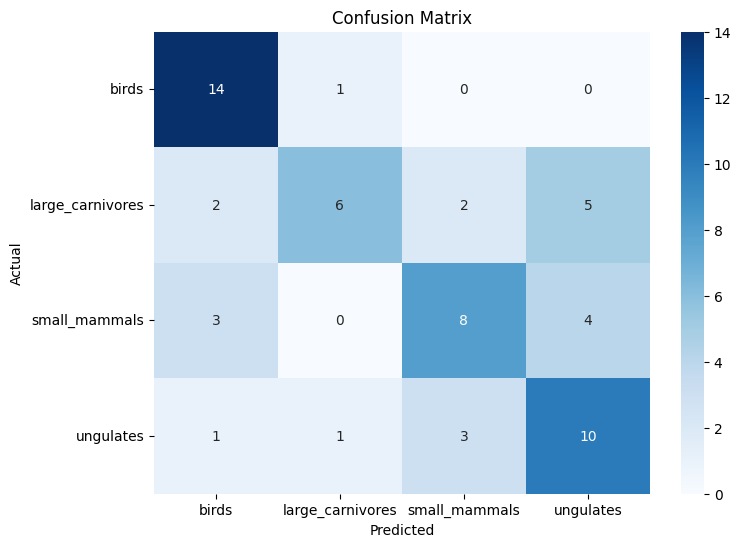

In [47]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.yticks(rotation=0)
Filename = 'confusion_matrix_values.png'
plt.savefig(Filename)
plt.show()

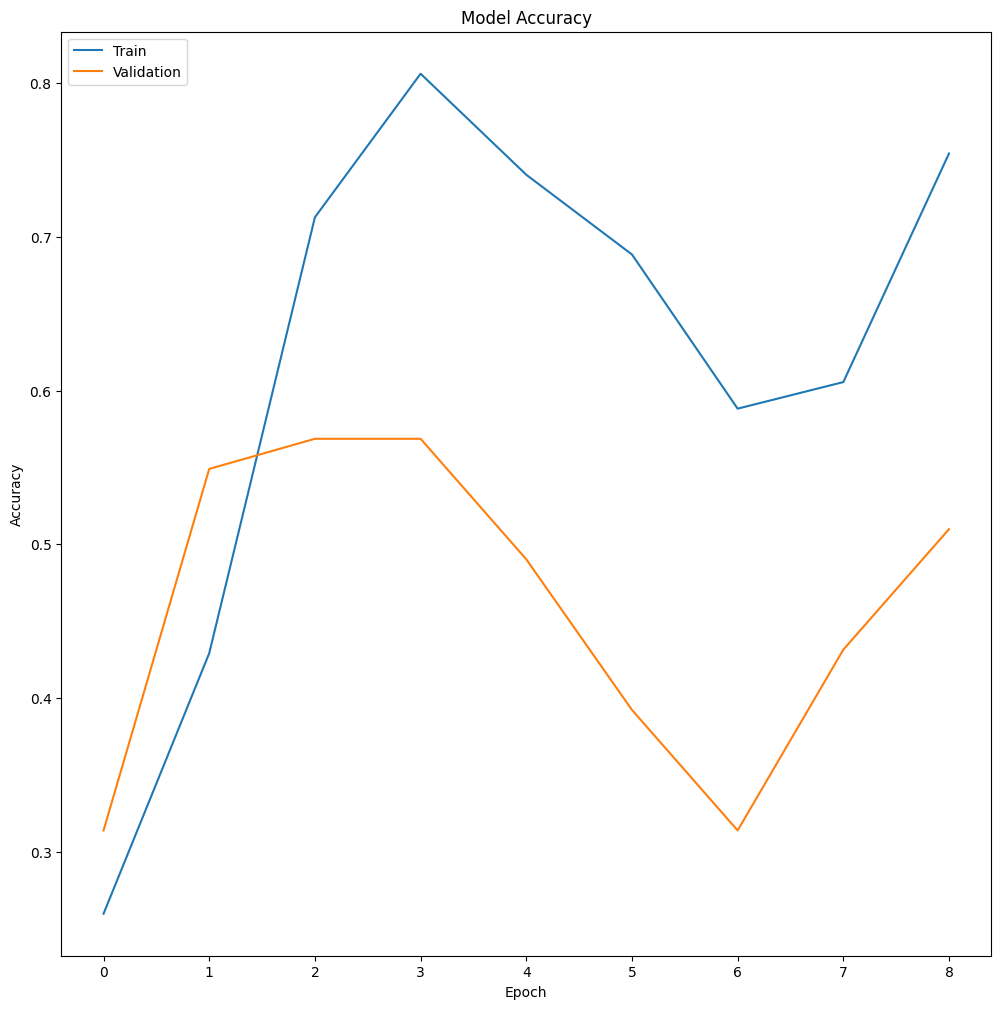

In [48]:
import matplotlib.pyplot as plt

# Plot training history
plt.figure(figsize=(12,12))

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
Filename = 'Line_charts_model_accuracy.png'
plt.savefig(Filename)

plt.show()

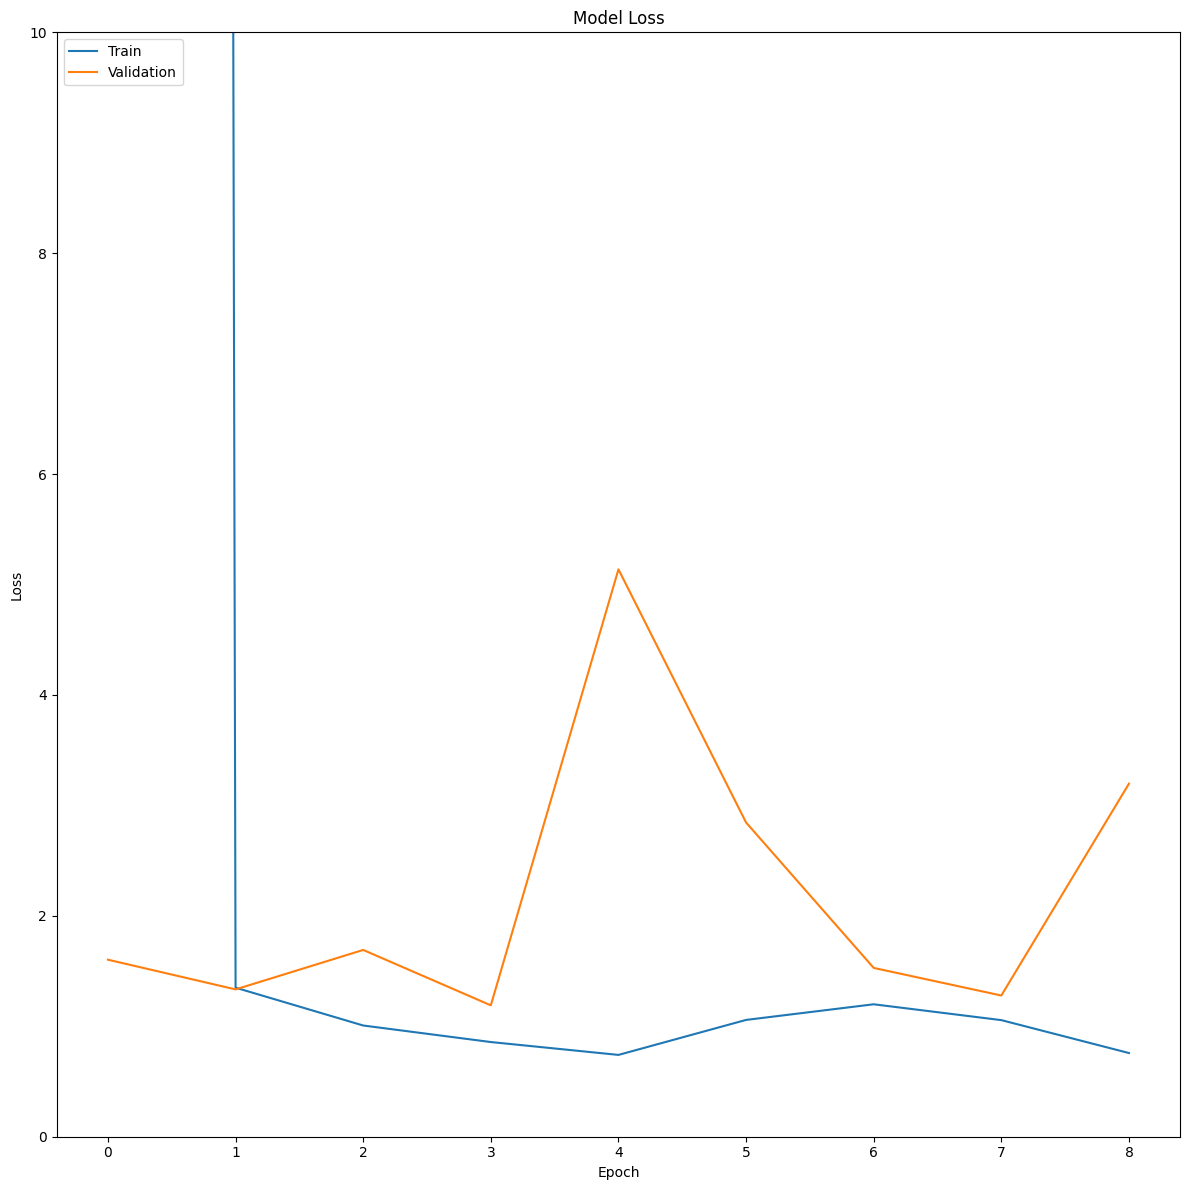

In [49]:
import matplotlib.pyplot as plt

# Plot training history
plt.figure(figsize=(12, 12))

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylim(0,10)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
Filename = 'Line_charts_model_loss.png'
plt.savefig(Filename)

plt.show()

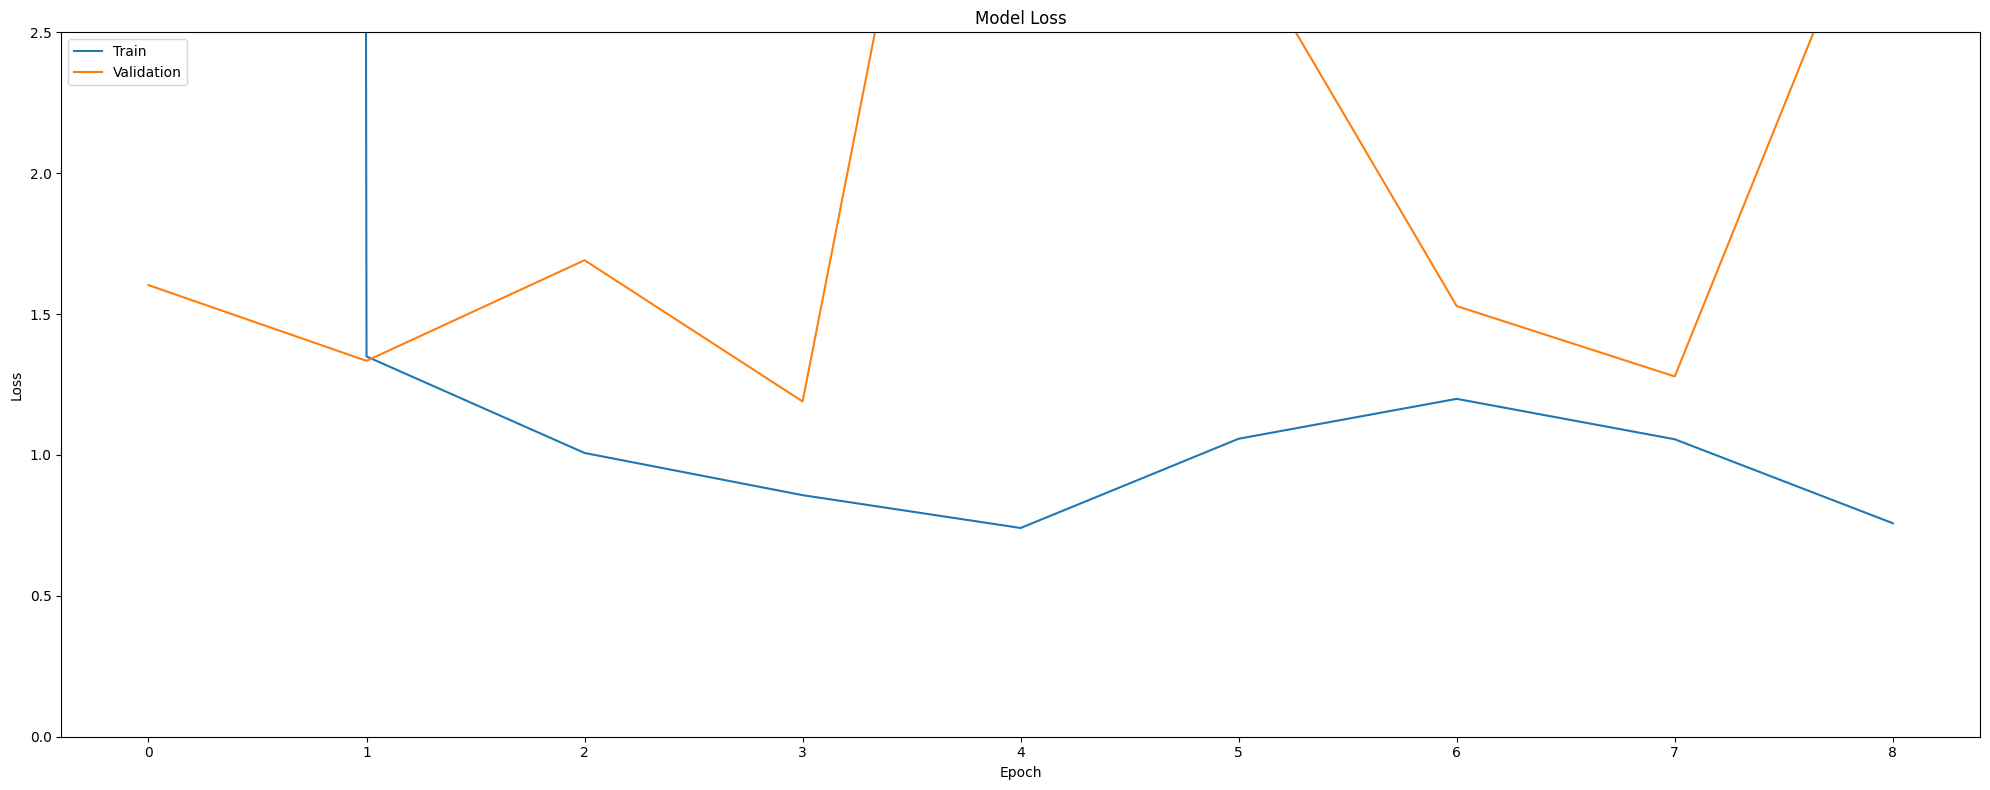

In [50]:
import matplotlib.pyplot as plt

# Plot training history
plt.figure(figsize=(20, 8))

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylim(0,2.5)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.yticks(rotation=0)
plt.tight_layout()
Filename = 'Line_charts_model_loss_zoomed_in.png'
plt.savefig(Filename)

plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Confusion Matrix (Raw Counts):
[[0.93333333 0.06666667 0.         0.        ]
 [0.13333333 0.4        0.13333333 0.33333333]
 [0.2        0.         0.53333333 0.26666667]
 [0.06666667 0.06666667 0.2        0.66666667]]


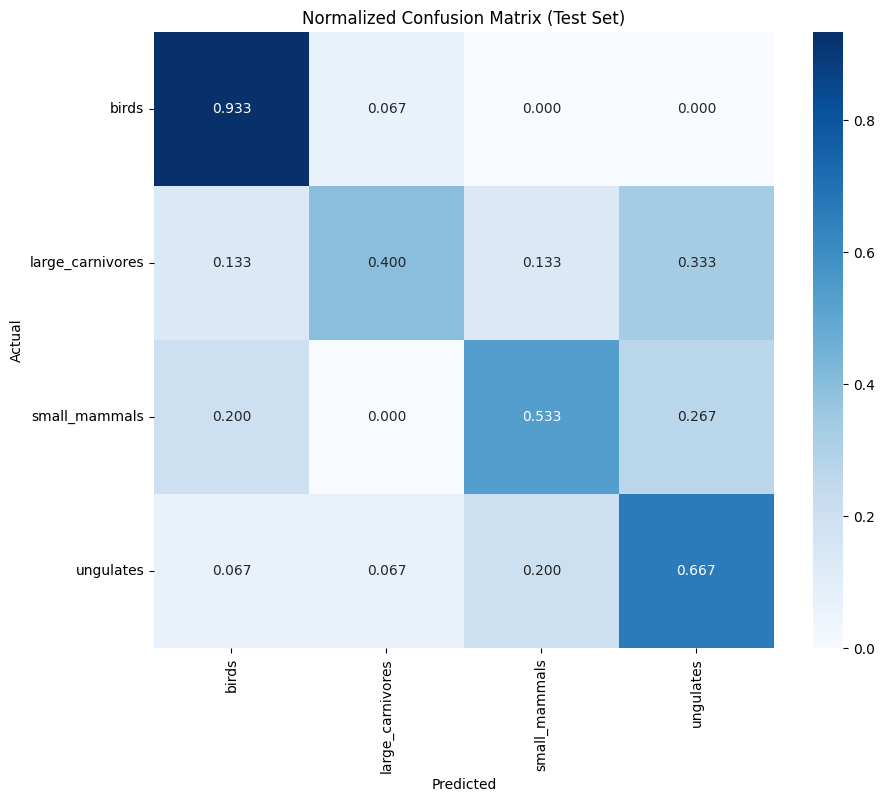

Sun Apr  5 02:00:13 2026


In [51]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')

# Normalize the confusion matrix to show percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# Print the confusion matrix (raw counts for reference)
print("Confusion Matrix (Raw Counts):")
print(cm)

# Visualize the confusion matrix with percentages
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.yticks(rotation=0)
plt.title('Normalized Confusion Matrix (Test Set)')
Filename = 'confusion_matrix_percent.png'
plt.savefig(Filename)
plt.show()
print(time.ctime())
